In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

In [23]:
df = pd.read_csv(r'c:\Users\BM\Downloads\sales.csv')
df

,order_id,date,region,product,category,customer_type,quantity,price,discount,sales
0,1,2024-04-12,East,Laptop,Electronics,Returning,8,590,0.09,4295.20
1,2,2024-12-14,South,Monitor,Accessories,Returning,2,262,0.18,429.68
2,3,2024-09-27,North,Phone,Accessories,New,5,512,0.09,2329.60
3,4,2024-04-16,West,Mouse,Electronics,Returning,1,485,0.09,441.35
4,5,2024-03-12,West,Phone,Electronics,Returning,7,332,0.22,1812.72
...,...,...,...,...,...,...,...,...,...,...
495,496,2024-11-20,South,Mouse,Accessories,Returning,6,314,0.23,1450.68
496,497,2024-01-04,North,Phone,Accessories,Returning,9,369,0.23,2557.17
497,498,2024-01-16,South,Keyboard,Electronics,Returning,6,722,0.14,3725.52
498,499,2024-10-06,North,Phone,Accessories,Returning,2,1449,0.12,2550.24


In [24]:
df.head(5)

,order_id,date,region,product,category,customer_type,quantity,price,discount,sales
0,1,2024-04-12,East,Laptop,Electronics,Returning,8,590,0.09,4295.20
1,2,2024-12-14,South,Monitor,Accessories,Returning,2,262,0.18,429.68
2,3,2024-09-27,North,Phone,Accessories,New,5,512,0.09,2329.60
3,4,2024-04-16,West,Mouse,Electronics,Returning,1,485,0.09,441.35
4,5,2024-03-12,West,Phone,Electronics,Returning,7,332,0.22,1812.72


In [25]:
df.head()

,order_id,date,region,product,category,customer_type,quantity,price,discount,sales
0,1,2024-04-12,East,Laptop,Electronics,Returning,8,590,0.09,4295.20
1,2,2024-12-14,South,Monitor,Accessories,Returning,2,262,0.18,429.68
2,3,2024-09-27,North,Phone,Accessories,New,5,512,0.09,2329.60
3,4,2024-04-16,West,Mouse,Electronics,Returning,1,485,0.09,441.35
4,5,2024-03-12,West,Phone,Electronics,Returning,7,332,0.22,1812.72


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       500 non-null    int64  
 1   date           500 non-null    str    
 2   region         500 non-null    str    
 3   product        500 non-null    str    
 4   category       500 non-null    str    
 5   customer_type  500 non-null    str    
 6   quantity       500 non-null    int64  
 7   price          500 non-null    int64  
 8   discount       500 non-null    float64
 9   sales          500 non-null    float64
dtypes: float64(2), int64(3), str(5)
memory usage: 39.2 KB


In [27]:
df.isnull().sum()

order_id         0
date             0
region           0
product          0
category         0
customer_type    0
quantity         0
price            0
discount         0
sales            0
dtype: int64

In [28]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
495    False
496    False
497    False
498    False
499    False
Length: 500, dtype: bool

In [29]:
df.describe()

,order_id,quantity,price,discount,sales
count,500.000000,500.000000,500.000000,500.00000,500.000000
mean,250.500000,4.968000,768.158000,0.14666,3333.059560
std,144.481833,2.569081,404.010497,0.08612,2693.185995
min,1.000000,1.000000,50.000000,0.00000,67.320000
25%,125.750000,3.000000,432.750000,0.08000,1120.867500
50%,250.500000,5.000000,742.000000,0.15000,2582.805000
75%,375.250000,7.000000,1094.500000,0.22000,4998.030000
max,500.000000,9.000000,1499.000000,0.30000,12700.800000


In [30]:
df.drop(columns=["discount","order_id"], inplace=True, errors="ignore")

In [31]:
df["date"] = pd.to_datetime(df["date"])

In [32]:
print(df.isnull().sum())

date             0
region           0
product          0
category         0
customer_type    0
quantity         0
price            0
sales            0
dtype: int64


In [21]:
df.duplicated().sum()

np.int64(0)

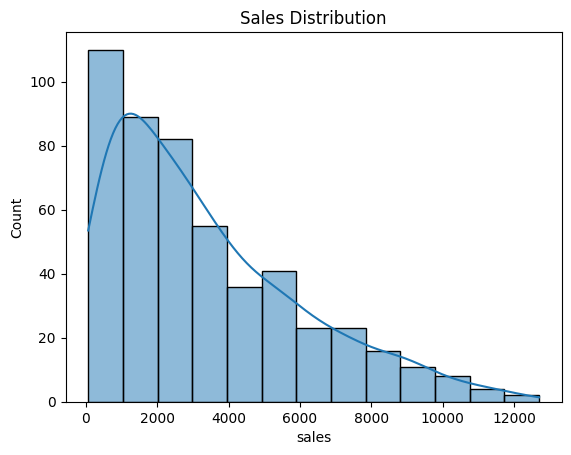

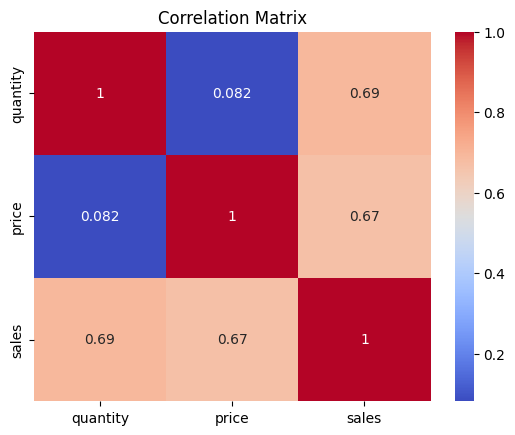

In [33]:
# sales distribution
sns.histplot(df["sales"], kde=True)
plt.title("Sales Distribution")
plt.show()

# correlation heatmap
numeric_df = df.select_dtypes(include=['int64','float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

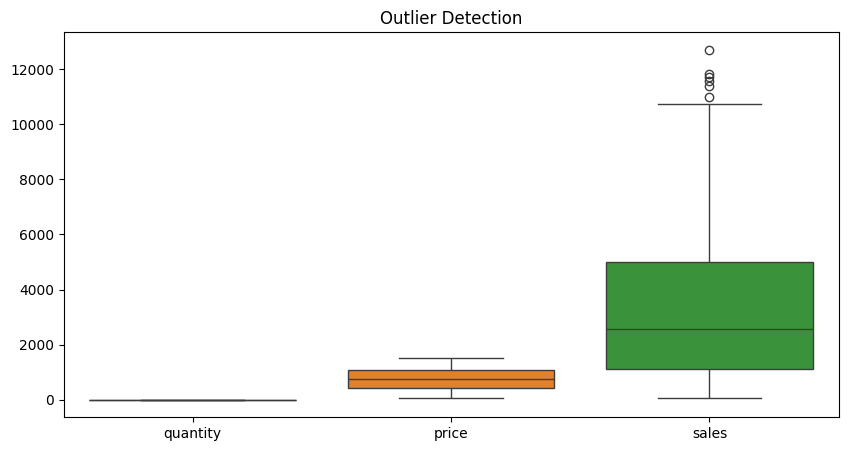

In [34]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df[['quantity','price','sales']])

plt.title("Outlier Detection")
plt.show()

In [35]:
# Calculate first quartile (25%)
Q1 = df['sales'].quantile(0.25)

# Calculate third quartile (75%)
Q3 = df['sales'].quantile(0.75)

# Calculate Interquartile Range
IQR = Q3 - Q1

# Define lower and upper limits for outliers
lower_limit = Q1 - 1.0 * IQR  #1.5 repersent Standard outlier detection increase or decrees csz extreme or too many values removed
upper_limit = Q3 + 1.0 * IQR

# Remove rows where sales value is outside the limits
df_clean = df[(df['sales'] >= lower_limit) & (df['sales'] <= upper_limit)]

# Print number of rows after removing outliers
print("Rows after removing outliers:", len(df_clean))

Rows after removing outliers: 476


In [36]:
# Detect outliers
outliers = df[(df['sales'] < lower_limit) | (df['sales'] > upper_limit)]

# Print all outlier rows
print("Outlier Data:")
outliers

Outlier Data:


,date,region,product,category,customer_type,quantity,price,sales
5,2024-07-07,West,Laptop,Electronics,New,8,1480,11721.60
11,2024-03-28,East,Phone,Accessories,Returning,7,1426,9383.08
20,2024-10-20,East,Monitor,Accessories,Returning,9,1440,12700.80
33,2024-09-27,North,Phone,Accessories,Returning,9,1297,10155.51
37,2024-12-29,East,Tablet,Accessories,Returning,9,1478,11572.74
57,2024-09-20,West,Laptop,Electronics,Returning,7,1450,10048.50
72,2024-07-20,West,Monitor,Electronics,Returning,8,1227,9521.52
131,2024-12-24,West,Laptop,Electronics,Returning,8,1191,9337.44
159,2024-06-18,South,Laptop,Accessories,Returning,9,1422,10622.34
170,2024-05-07,North,Monitor,Electronics,New,9,1059,9054.45


In [37]:

from sklearn.preprocessing import LabelEncoder
#lable the data
le = LabelEncoder()

df_clean["customer_type"] = le.fit_transform(df_clean["customer_type"])

In [38]:
df_clean

,date,region,product,category,customer_type,quantity,price,sales
0,2024-04-12,East,Laptop,Electronics,1,8,590,4295.20
1,2024-12-14,South,Monitor,Accessories,1,2,262,429.68
2,2024-09-27,North,Phone,Accessories,0,5,512,2329.60
3,2024-04-16,West,Mouse,Electronics,1,1,485,441.35
4,2024-03-12,West,Phone,Electronics,1,7,332,1812.72
...,...,...,...,...,...,...,...,...
495,2024-11-20,South,Mouse,Accessories,1,6,314,1450.68
496,2024-01-04,North,Phone,Accessories,1,9,369,2557.17
497,2024-01-16,South,Keyboard,Electronics,1,6,722,3725.52
498,2024-10-06,North,Phone,Accessories,1,2,1449,2550.24


In [39]:
df_encoded = pd.get_dummies(df_clean, columns=["region","product","category"])  #nominal encode
df_encoded

,date,customer_type,quantity,price,sales,region_East,region_North,region_South,region_West,product_Keyboard,product_Laptop,product_Monitor,product_Mouse,product_Phone,product_Tablet,category_Accessories,category_Electronics
0,2024-04-12,1,8,590,4295.20,True,False,False,False,False,True,False,False,False,False,False,True
1,2024-12-14,1,2,262,429.68,False,False,True,False,False,False,True,False,False,False,True,False
2,2024-09-27,0,5,512,2329.60,False,True,False,False,False,False,False,False,True,False,True,False
3,2024-04-16,1,1,485,441.35,False,False,False,True,False,False,False,True,False,False,False,True
4,2024-03-12,1,7,332,1812.72,False,False,False,True,False,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,2024-11-20,1,6,314,1450.68,False,False,True,False,False,False,False,True,False,False,True,False
496,2024-01-04,1,9,369,2557.17,False,True,False,False,False,False,False,False,True,False,True,False
497,2024-01-16,1,6,722,3725.52,False,False,True,False,True,False,False,False,False,False,False,True
498,2024-10-06,1,2,1449,2550.24,False,True,False,False,False,False,False,False,True,False,True,False


In [40]:
X = df_encoded.drop(columns=["sales","date"])
y = df_encoded["sales"]

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [42]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [43]:
from sklearn.metrics import r2_score, mean_squared_error

print("R2 Score:", r2_score(y_test, y_pred))

print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.8502810939370058
MSE: 829265.9488022561


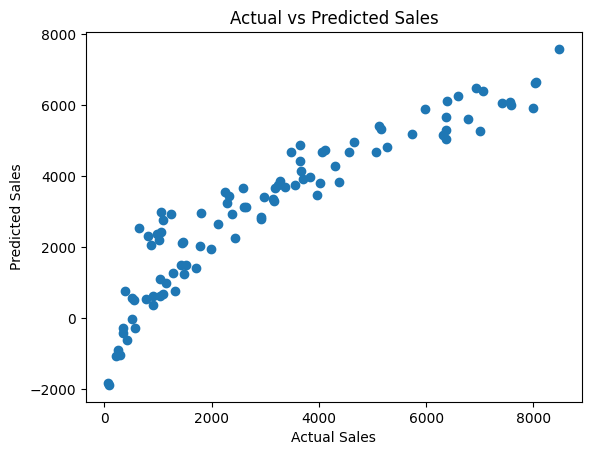

In [44]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

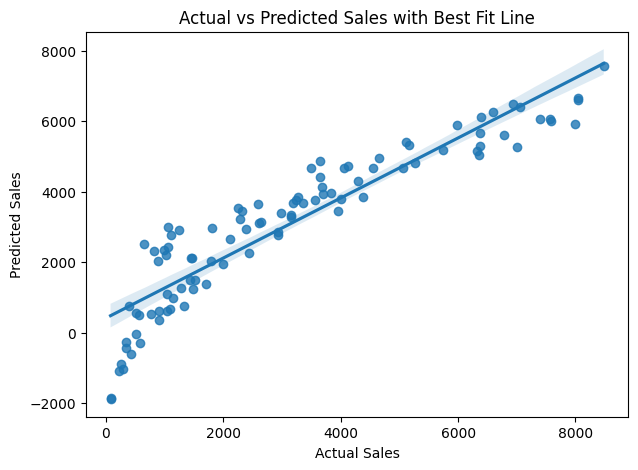

In [45]:
plt.figure(figsize=(7,5))

sns.regplot(x=y_test, y=y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales with Best Fit Line")

plt.show()

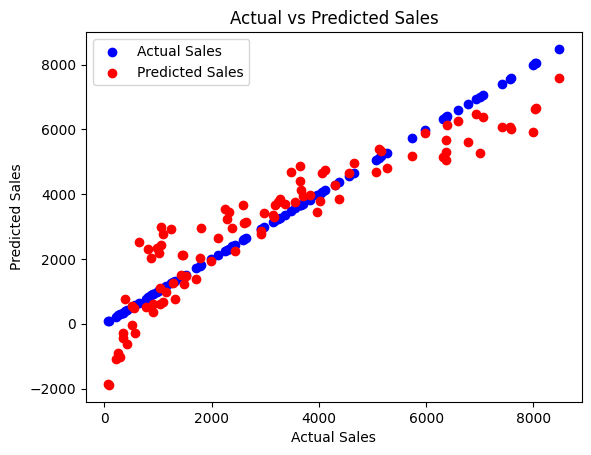

In [46]:
# Actual values (blue)
plt.scatter(y_test, y_test, color='blue', label="Actual Sales")

# Predicted values (red)
plt.scatter(y_test, y_pred, color='red', label="Predicted Sales")

# Axis labels
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

# Title
plt.title("Actual vs Predicted Sales")

# Legend to show colors
plt.legend()

plt.show()

In [47]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

In [48]:

poly_model = LinearRegression()

poly_model.fit(X_poly_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [50]:
y_pred_poly = poly_model.predict(X_poly_test)
from sklearn.metrics import r2_score, mean_squared_error

print("Polynomial R2:", r2_score(y_test, y_pred_poly))
print("Polynomial MSE:", mean_squared_error(y_test, y_pred_poly))

Polynomial R2: 0.9703425863420746
Polynomial MSE: 164267.05165553812


In [51]:
df.columns

Index(['date', 'region', 'product', 'category', 'customer_type', 'quantity',
       'price', 'sales'],
      dtype='str')

In [52]:
# Features and target
X = df[['price']]
y = df['sales']

# Split data (80% train, 20% test)_

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [53]:
# PART 1: LINEAR REGRESSION MODEL

# Create and train the linear regression model
linear_model = LinearRegression()           # Initialize the model
linear_model.fit(X_train, y_train)           # Train on training data

# Make predictions using the trained linear model
y_pred_linear = linear_model.predict(X)      # Predict on ALL data (for visualization)

In [54]:
# PART 2: POLYNOMIAL REGRESSION MODEL
# Transform features to polynomial features (degree 2)
poly_features = PolynomialFeatures(degree=2)  # Create polynomial transformer
X_poly_train = poly_features.fit_transform(X_train)  # Transform training data
X_poly_all = poly_features.transform(X)        # Transform all data (for visualization)

# Create and train polynomial regression model
poly_model = LinearRegression()                 # Initialize linear model for polynomial data
poly_model.fit(X_poly_train, y_train)           # Train on polynomial features

# Make predictions using polynomial model
y_pred_poly = poly_model.predict(X_poly_all)    # Predict on all data

c:\Users\BM\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


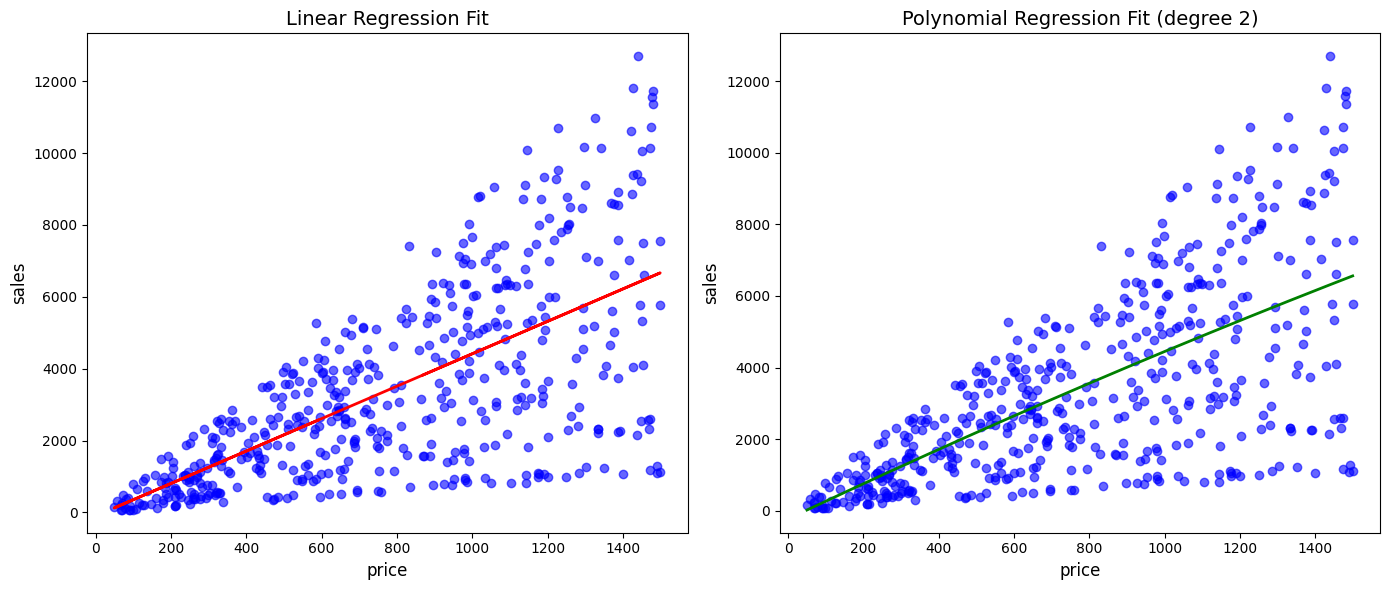

In [58]:
# PART 3: CREATE SMOOTH CURVE FOR POLYNOMIAL

# Create dense grid for smooth polynomial curve
X_smooth = np.arange(start=X.values.flatten().min(), stop=X.values.flatten().max(), step=0.1)  # Dense points
X_smooth = X_smooth.reshape(-1, 1)              # Reshape for sklearn


# PART 4: VISUALIZATION - COMPARE BOTH MODELS

# Create figure with two subplots side by side
plt.figure(figsize=(14, 6))

# ----- LEFT PLOT: Linear Regression -----
plt.subplot(1, 2, 1)                           # 1 row, 2 columns, position 1

plt.scatter(X, y, color='blue', alpha=0.6)     # Plot actual data points
plt.plot(X, y_pred_linear, color='red', linewidth=2)  # Plot linear fit

plt.title("Linear Regression Fit", fontsize=14) # Add title
plt.xlabel("price", fontsize=12)                # X-axis label
plt.ylabel("sales", fontsize=12)               # Y-axis label

# ----- RIGHT PLOT: Polynomial Regression -----
plt.subplot(1, 2, 2)                           # 1 row, 2 columns, position 2

plt.scatter(X, y, color='blue', alpha=0.6)     # Plot actual data points
# Plot smooth polynomial curve using dense grid points
plt.plot(X_smooth, poly_model.predict(poly_features.transform(X_smooth)), 
         color='green', linewidth=2)

plt.title("Polynomial Regression Fit (degree 2)", fontsize=14)  # Add title
plt.xlabel("price", fontsize=12)                # X-axis label
plt.ylabel("sales", fontsize=12)               # Y-axis label

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plot
plt.show()

# KEY DIFFERENCES EXPLAINED:
# ============================================
# Linear Regression: Fits a straight line to data (simple, may underfit)
# Polynomial Regression: Fits curved line (more flexible, may overfit)
# 
# Why use X_smooth for polynomial plot?
# - Shows a continuous curve instead of jagged lines
# - Better visualization of the polynomial function
# - Makes the curved nature of the fit more obvious

In [59]:
from sklearn.metrics import r2_score

print("Linear R2:", r2_score(y, y_pred_linear))
print("Polynomial R2:", r2_score(y, y_pred_poly))

Linear R2: 0.4466640436911826
Polynomial R2: 0.4466177440507546


<Axes: >

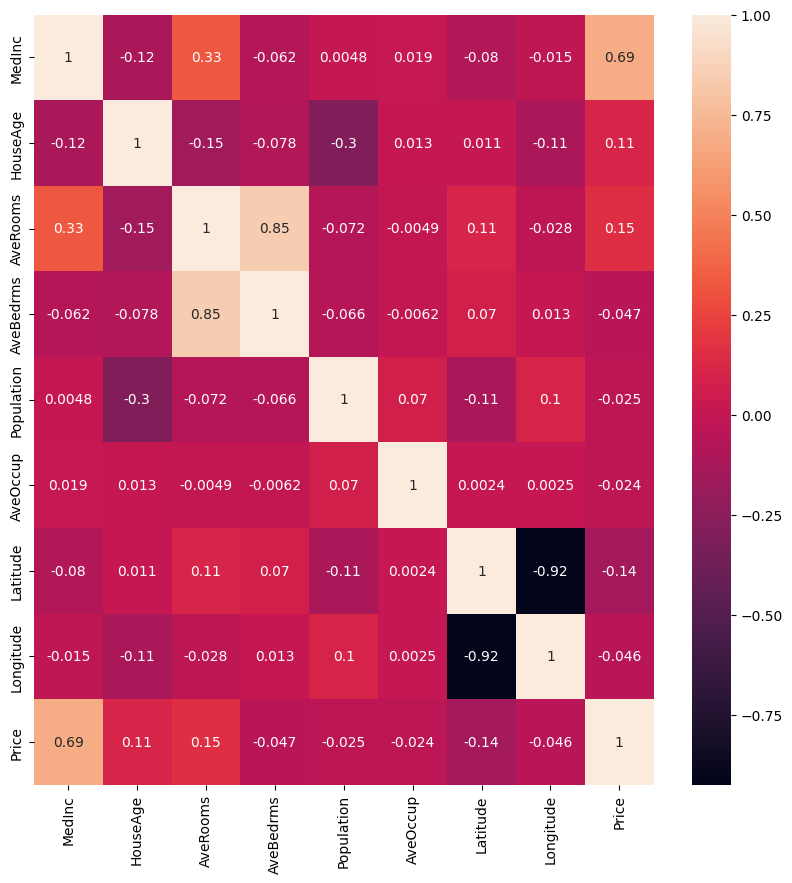

In [61]:
#libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, RidgeCV, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing
#data
boston = fetch_california_housing()
boston_df=pd.DataFrame(boston.data,columns=boston.feature_names)
#target variable
boston_df['Price']=boston.target
#preview
boston_df.head()

#Exploration
plt.figure(figsize = (10, 10))
sns.heatmap(boston_df.corr(), annot = True)

In [63]:
boston_df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'Price'],
      dtype='str')

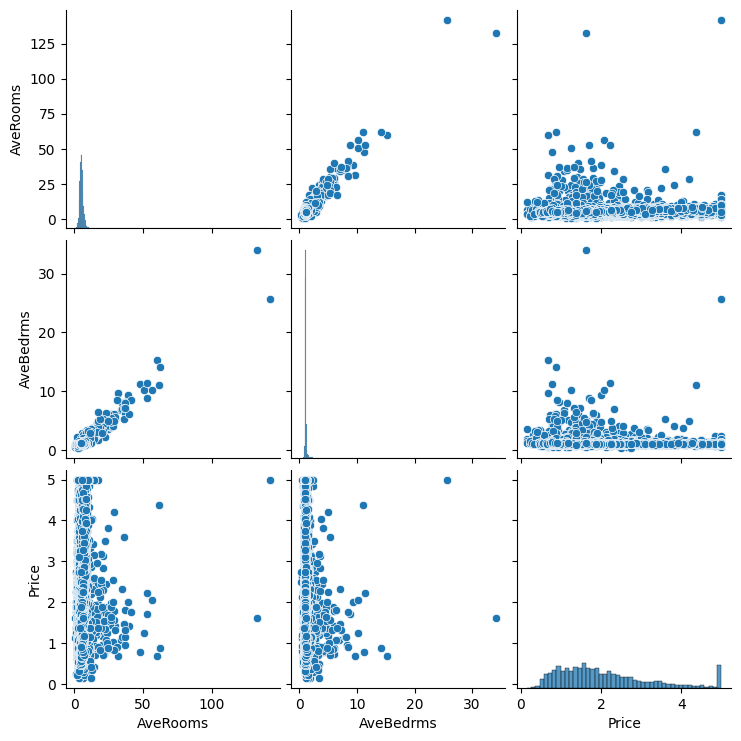

In [69]:
#There are cases of multicolinearity, we will drop a few columns
boston_df.drop(columns = ["Latitude", "Longitude"], inplace = True)

#pairplot
sns.pairplot(boston_df)

#we will log the pric Column
boston_df.Price = np.log(boston_df.Price)
